In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [28]:
BATCH_SIZE = 10
LEARNIG_LATE = 0.2
EPOCHS = 200

In [29]:
# デバイスの確認
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)

train_dataset = datasets.MNIST(root = "./data", train = True, transform = transforms.Compose([transforms.ToTensor()]), download = True)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2, pin_memory = True)

# モデルの定義
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = torch.sigmoid(x)
        x = self.fc2(x)
        return x

Using device: cuda
PyTorch version: 2.9.0+cu126


In [30]:
n_train = 60000
batch_size = 10         # 論文 
lambda_l2 = 1e-4        # 論文 [cite: 427]
total_epochs = 100      # Figure 4 の x軸 (#grad/n) が 200 までのため [cite: 416]
lr_init = 0.5           # 代表的な初期学習率
gamma = 0.95 

model = Model().to(device)
criterion = nn.CrossEntropyLoss()

# --- 3. 全データに対する損失 P(w) を計算する関数 ---
def compute_full_objective(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item() * data.size(0)

    # L2項の計算 (P(w) = loss + 0.5 * lambda * ||w||^2)
    l2_reg = sum(torch.norm(p)**2 for p in model.parameters())
    return (total_loss / n_train) + (0.5 * lambda_l2 * l2_reg.item())

In [31]:
#SGD
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNIG_LATE, weight_decay = lambda_l2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

history_x = []
SGD_train_loss = []

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")
    model.train()
    pb = tqdm(train_loader)
    for images, labels in pb:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # 各エポック終了時の計算コスト (#grad/n) と損失を記録
    current_x = (epoch + 1) # 1エポック = n回勾配計算なので x = epoch
    current_loss = compute_full_objective(model, train_loader)

    history_x.append(current_x)
    SGD_train_loss.append(current_loss)
    
    scheduler.step() # 学習率の更新
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {current_loss:.6f}")

epoch; 1


100%|██████████| 6000/6000 [00:07<00:00, 779.66it/s]


Epoch 1/200, Loss: 0.205533
epoch; 2


100%|██████████| 6000/6000 [00:07<00:00, 782.92it/s]


Epoch 2/200, Loss: 0.166056
epoch; 3


...

Epoch 198/200, Loss: 0.099999
epoch; 199


100%|██████████| 6000/6000 [00:08<00:00, 737.98it/s]


Epoch 199/200, Loss: 0.099999
epoch; 200


100%|██████████| 6000/6000 [00:06<00:00, 872.91it/s]


Epoch 200/200, Loss: 0.099999


In [32]:
class SVRG_SGD(optim.Optimizer):
    def __init__(self, params, lr = LEARNIG_LATE, weight_decay = 0):
        defaults = dict(lr = lr, weight_decay = weight_decay)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        """
            全データでの勾配を計算する関数
            loss_func; ミニバッチの誤差の平均を返す関数
        """
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # full_grad，prev_pを初期化
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['prev_p'] = torch.clone(p) # prev_pの初期値はパラメータ

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)

    def culc_prev_grads(self, model, X, T, loss_func):
        # prev_pに切り替え
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"]) # パラメータをprev_vに変換

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_vに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                z = state['z']
                prev_grad = state["prev_grad"]
                # 補正勾配を更新
                v = grad - prev_grad + z

                # パラメータを更新
                p.sub_(v, alpha = lr).add_(p, alpha = -lr * group['weight_decay']) # L2正則化項の更新

        return loss
    
    @torch.no_grad()
    def sgd_step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()

                p.sub_(grad, alpha = lr).add_(p, alpha = -lr * group['weight_decay']) # L2正則化項の更新

        return loss

In [33]:
#SVRG
snapshot_epoch = 5
optimizer = SVRG_SGD(model.parameters(), lr = LEARNIG_LATE, weight_decay=lambda_l2)
# 指数減衰スケジューラ: η(t) = η0 * a^(epoch) 
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

SVRG_x = []
SVRG_train_loss = []
current_x = 0

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")

    scheduler.step() # 学習率の更新

    model.train()
    train_loss = 0
    pb = tqdm(train_loader)

    if epoch >= 10 and epoch % snapshot_epoch == 0:
        optimizer.calc_full_grads(model, train_loader, criterion)
        current_x += 1
        #print(f"Snapshot taken at epoch {epoch+1}, #grad/n = {current_x}")

    for data, target in pb:
        data, target = data.to(device), target.to(device)
        
        # 最初の数エポックは通常のSGDで更新
        if epoch < 10:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.sgd_step() 
        
        else:   
            optimizer.culc_prev_grads(model, data, target, criterion)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    
    # 各エポック終了時の計算コスト (#grad/n) と損失を記録
    if epoch < 10:
        current_x += 1 # 1エポック = n回勾配計算なので x = epoch
    else:
        current_x += 2
        
    current_loss = compute_full_objective(model, train_loader)
    
    SVRG_x.append(current_x)
    SVRG_train_loss.append(current_loss)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {current_loss:.6f}")
    
    if current_x >= 200:
        break

epoch; 1


100%|██████████| 6000/6000 [00:07<00:00, 812.29it/s]


Epoch 1/200, Loss: 0.108688
epoch; 2


100%|██████████| 6000/6000 [00:07<00:00, 750.47it/s]


Epoch 2/200, Loss: 0.106627
epoch; 3


...

Epoch 94/200, Loss: 0.097399
epoch; 95


100%|██████████| 6000/6000 [00:19<00:00, 310.95it/s]


Epoch 95/200, Loss: 0.097398
epoch; 96


100%|██████████| 6000/6000 [00:28<00:00, 209.58it/s]


Epoch 96/200, Loss: 0.097397


In [38]:
print(history_x)
print(SVRG_x)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 15, 17, 19, 21, 24, 26, 28, 30, 32, 35, 37, 39, 41, 43, 46, 48, 50, 52,

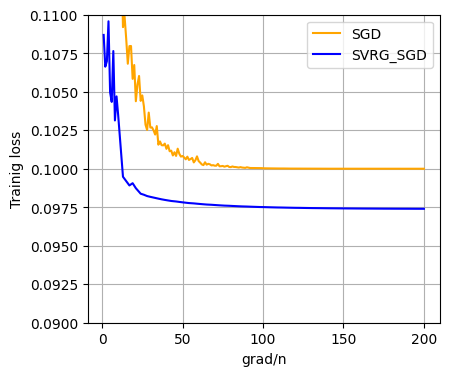

In [37]:
fig = plt.figure(figsize = (10, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(history_x, SGD_train_loss, label = "SGD", color = "orange")
ax.plot(SVRG_x, SVRG_train_loss ,label = "SVRG_SGD", color = "blue")
ax.set_xlabel("grad/n")
ax.set_ylabel("Trainig loss")
ax.set_ylim([0.09 ,0.11])
ax.grid()
ax.legend()